# Rapport de Projet : Dimensionnement d'un Stockage Embarqué dans un Tramway

## Compréhension et Implantation du Modèle de Système

### Simulation du Déplacement du Train

Dans cette section, nous allons simuler le déplacement du train le long de la ligne et calculer les grandeurs électriques à chaque pas de temps. Nous allons d'abord simuler sans batterie, puis ajouter la batterie et analyser les résultats.

### Calcul des Résistances des Segments

Pour chaque position du train, nous devons calculer les résistances des segments de la ligne aérienne de contact (LAC) et des rails. Ces résistances dépendent de la position actuelle du train et des résistances linéiques de la LAC et des rails.

Les formules utilisées sont les suivantes :

- R_LAC1 = rho_LAC * x_pos
- R_rail1 = rho_rail * x_pos
- R_LAC2 = rho_LAC * (x_fin - x_pos)
- R_rail2 = rho_rail * (x_fin - x_pos)

Où :
- x_pos est la position actuelle du train.
- x_fin est la position finale de la ligne (ici, la position à l'indice 633).
- rho_LAC et rho_rail sont les résistances linéiques de la LAC et des rails, respectivement.

### Calcul des Résistances Équivalentes

Ensuite, nous calculons les résistances équivalentes des deux branches du circuit en utilisant les résistances internes des sous-stations.

- R_haut = R_LAC1 + R_rail1 + R_internal
- R_bas = R_LAC2 + R_rail2 + R_internal

La résistance équivalente totale du circuit est alors donnée par :

- R_eq = (R_haut * R_bas) / (R_haut + R_bas)

### Résolution de l'Équation Quadratique pour V_train

Pour déterminer la tension aux bornes du train, nous résolvons une équation quadratique. La tension V_train est solution de l'équation suivante :

- V_train^2 - V_source * V_train + R_total * P_train = 0

Le discriminant de cette équation est :

- Delta = V_source^2 - 4 * R_total * P_train

Si Delta >= 0, alors :

- V_train = (V_source + sqrt(Delta)) / 2

Si Delta < 0, nous fixons V_train à 500 V, car la puissance demandée est trop grande pour être fournie par la ligne.

### Calcul du Courant Consommé

Le courant consommé par le train est calculé en utilisant la loi d'Ohm :

- I_train = (V_source - V_train) / R_total

Si V_train est nul, nous fixons I_train à :

- I_train = (V_source - 500) / R_total

### Calcul de la Puissance Fournie par la Sous-Station

La puissance fournie par la sous-station est calculée en multipliant la tension source par le courant consommé :

- P_substation = V_source * I_train

### Calcul du Courant dans Chaque Branche

Enfin, nous calculons le courant dans chaque branche du circuit :

- I1 = (V_source - V_train) / R_haut
- I2 = (V_source - V_train) / R_bas


In [19]:
import numpy as np
import matplotlib.pyplot as plt

# Charger les données du fichier
data = np.loadtxt('marche.txt', delimiter='\t')  # Charger les colonnes séparées par une tabulation
time = data[:, 0]  # Première colonne : temps (secondes)
position = data[:, 1]  # Deuxième colonne : position (mètres)

# Données électriques
V_source = 790  # Tension source (V)
R_internal = 33e-3  # Résistance interne (ohms)
rho_LAC = 95e-6  # Résistance linéique de la LAC (ohms/m)
rho_rail = 10e-6  # Résistance linéique des rails (ohms/m)

# Simulation de la puissance demandée (exemple fictif à modifier selon votre projet)
# Données mécaniques
M = 70e3  # Masse du train (kg)
g = 9.81  # Accélération gravitationnelle (m/s^2)
alpha = 0.01  # Pente (rad), exemple : 0.01 = 1% de pente
eta = 0.8  # Rendement du moteur électrique (80%)
P_bord = 35e3  # Puissance consommée à bord (W)

# Coefficients pour la force résistive
A0 = 780  # N
A1 = 6.4  # N/tonne
B0 = 0  # N
B1 = 0.14  # N/tonne/(km/h)
C0 = 0.3634  # N/(km/h)^2
C1 = 0  # N

# Vitesse et accélération du train (calculées à partir de la position)
vitesse = np.gradient(position, time)  # Vitesse en m/s (dérivée de la position)
acceleration = np.gradient(vitesse, time)  # Accélération en m/s^2 (dérivée de la vitesse)

# Initialisation des résultats
F_resistive_results = []
F_motrice_results = []
P_mecanique_results = []
P_electrique_results = []

# Simulation temporelle
for i in range(len(time)):
    v = vitesse[i]  # Vitesse actuelle (m/s)
    a = acceleration[i]  # Accélération actuelle (m/s^2)
    v_kmh = v * 3.6  # Conversion en km/h

    # Calcul de la force résistive
    F_resistive = (A0 + A1 * M / 1e3) + (B0 + B1 * M / 1e3) * v_kmh + (C0 + C1 * M / 1e3) * v_kmh**2
    F_resistive_results.append(F_resistive)

    # Calcul de la force motrice
    F_motrice = M * a + M * g * np.sin(alpha) + F_resistive
    F_motrice_results.append(F_motrice)

    # Calcul de la puissance mécanique
    P_mecanique = F_motrice * v  # Puissance mécanique en W
    P_mecanique_results.append(P_mecanique)

    # Calcul de la puissance électrique
    if P_mecanique > 0:
        P_electrique = P_mecanique / eta + P_bord
    else:
        P_electrique = P_mecanique * eta + P_bord  

    P_electrique_results.append(P_electrique) 

# Conversion en tableaux NumPy pour manipulation
F_resistive_results = np.array(F_resistive_results)
F_motrice_results = np.array(F_motrice_results)
P_mecanique_results = np.array(P_mecanique_results)
P_electrique_tarin= np.array(P_electrique_results)



# Initialisation des résultats
V_train_results = []
I_train_results = []
power_substation = []
I11 = []
I22 = []


# Simulation temporelle
for i in range(len(time)):
    x_pos = position[i]  # Position actuelle du train
    P_train = P_electrique_tarin[i]# Puissance de lAC
    
    # Calcul des résistances des segments
    R_LAC1 = rho_LAC * x_pos  # Résistance de la première branche de la LAC
    R_rail1 = rho_rail * x_pos  # Résistance de la première branche des rails
    R_LAC2 = rho_LAC * ( position[633] - x_pos)  # Résistance de la deuxième branche de la LAC
    R_rail2 = rho_rail * ( position[633] - x_pos) # Résistance de la deuxième branche des rails

    # Résistance équivalente de chaque branche 
    R_haut = R_LAC1 + R_rail1 + R_internal
    R_bas = R_LAC2 + R_rail2 + R_internal

    
    R_eq = (R_haut * R_bas) / (R_haut + R_bas) # Résistance équivalente 

    # Résistance totale (inclut la résistance interne de la sous-station)
    R_total = R_eq

    # Résolution de l'équation quadratique pour V_train
    delta = V_source**2 - 4 * R_total * P_train
    if delta >= 0:
        V_train = (V_source + np.sqrt(delta)) / 2
    else:
        V_train = 500  # Pas de solution si la puissance demandée est trop grande

    # Calcul du courant consommé
    if V_train > 0:
        I_train = (V_source - V_train ) / R_total
    else:
        I_train = (V_source - 500) /R_total # Pas de courant si V_train est nul

    # Puissance fournie par la sous-station
    P_substation = V_source * I_train
    # Calcul du couran de courant de chaque branche 
    I_1 = (V_source - V_train ) / (R_haut)
    I_2 = (V_source - V_train ) / (R_bas)

    # Stockage des résultats
    V_train_results.append(V_train)
    I_train_results.append(I_train)
    power_substation.append(P_substation)
    I11.append(I_1)
    I22.append(I_2)

# Conversion en tableaux NumPy pour manipulation
V_train_resultss = np.array(V_train_results)
I_train_resultss = np.array(I_train_results)
power_substationn = np.array(power_substation)
I1 = np.array(I11)
I2 = np.array(I22)



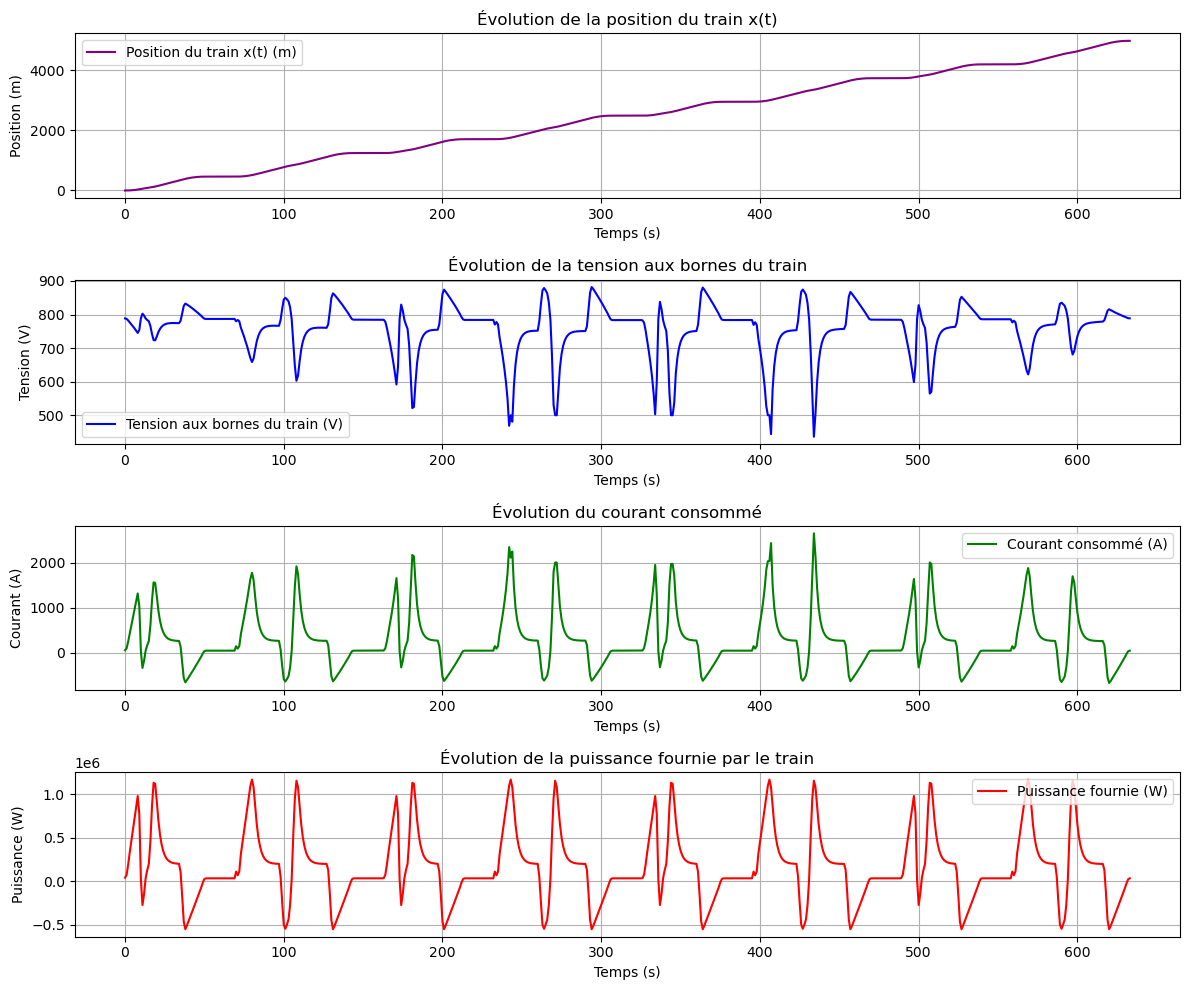

In [21]:
# Visualisation des résultats
plt.figure(figsize=(12, 10))

# Tracé de la position du train en fonction du temps
plt.subplot(4, 1, 1)
plt.plot(time, position, label="Position du train x(t) (m)", color="purple")
plt.xlabel("Temps (s)")
plt.ylabel("Position (m)")
plt.title("Évolution de la position du train x(t)")
plt.legend()
plt.grid()

# Tension aux bornes du train
plt.subplot(4, 1, 2)
plt.plot(time, V_train_results, label="Tension aux bornes du train (V)", color="blue")
plt.xlabel("Temps (s)")
plt.ylabel("Tension (V)")
plt.title("Évolution de la tension aux bornes du train")
plt.legend()
plt.grid()

# Courant consommé par le train
plt.subplot(4, 1, 3)
plt.plot(time, I_train_results, label="Courant consommé (A)", color="green")
plt.xlabel("Temps (s)")
plt.ylabel("Courant (A)")
plt.title("Évolution du courant consommé")
plt.legend()
plt.grid()

# Puissance fournie par la sous-station
plt.subplot(4, 1, 4)
plt.plot(time, P_electrique_tarin, label="Puissance fournie (W)", color="red")
plt.xlabel("Temps (s)")
plt.ylabel("Puissance (W)")
plt.title("Évolution de la puissance fournie par le train")
plt.legend()
plt.grid()

plt.tight_layout()
plt.show()

 # Ajout de la Batterie et Gestion de l'Énergie


Dans cette section, nous allons ajouter une batterie embarquée au modèle de simulation du tramway. Nous allons définir un seuil de puissance pour la sous-station et gérer la charge et la décharge de la batterie en fonction de la puissance demandée par le train. Enfin, nous allons calculer l'énergie de la batterie et la chute de tension aux bornes du train.

## Paramètres de la Batterie

Nous définissons les paramètres suivants pour la batterie :

- **Seuil de puissance (Seuil)**: 0.8 MW
- **Capacité maximale de la batterie (E_batterie_max)**: 1 MWh
- **Capacité initiale de la batterie (E_batterie)**: 0 Wh

## Calcul de l'Énergie et Gestion de la Puissance

Pour chaque pas de temps, nous calculons la puissance demandée par le train et gérons la charge et la décharge de la batterie en fonction du seuil de puissance défini.

### Initialisation des Variables

Nous initialisons les variables suivantes à chaque itération :

- **Delta de temps (dt)**: Calculé comme la différence entre les temps consécutifs.
- **Puissance demandée par le train (P_train)**: Extraite des résultats précédents.
- **Puissance du rhéostat (P_rh)**: Initialisée à zéro à chaque itération.

### Gestion de la Puissance Positive (Décharge)

Si la puissance demandée par le train est positive (décharge de la batterie) :

1. **Si la puissance demandée est inférieure ou égale au seuil** :
   - Toute la puissance est fournie par la sous-station.
   - La batterie n'est pas déchargée.

   \[
   P_{\text{lac}} = P_{\text{train}}
   \]
   \[
   P_{\text{batt}} = 0
   \]

2. **Si la puissance demandée est supérieure au seuil** :
   - La sous-station fournit la puissance jusqu'au seuil.
   - Le reste de la puissance est fourni par la batterie.
   - L'énergie de la batterie est mise à jour en fonction de la puissance fournie et du delta de temps.

   \[
   P_{\text{lac}} = \text{Seuil}
   \]
   \[
   P_{\text{batt}} = P_{\text{train}} - P_{\text{lac}}
   \]
   \[
   E_{\text{batterie}} -= P_{\text{batt}} \cdot dt
   \]

### Gestion de la Puissance Négative (Recharge)

Si la puissance demandée par le train est négative (recharge de la batterie) :

1. **Si l'énergie de la batterie est inférieure à la capacité maximale** :
   - La sous-station ne fournit pas de puissance.
   - Le rhéostat est inactif.
   - La batterie est rechargée avec la puissance négative.
   - L'énergie de la batterie est mise à jour en fonction de la puissance de recharge et du delta de temps.

   \[
   P_{\text{lac}} = 0
   \]
   \[
   P_{\text{rh}} = 0
   \]
   \[
   P_{\text{batt}} = P_{\text{train}}
   \]
   \[
   E_{\text{batterie}} -= P_{\text{batt}} \cdot dt
   \]

2. **Si l'énergie de la batterie est égale à la capacité maximale** :
   - La sous-station ne fournit pas de puissance.
   - La batterie est rechargée au maximum.
   - Le rhéostat dissipe l'excès de puissance.

   \[
   P_{\text{lac}} = 0
   \]
   \[
   P_{\text{batt}} = \frac{E_{\text{batterie\_max}}}{dt}
   \]
   \[
   P_{\text{rh}} = P_{\text{batt}} - P_{\text{train}}
   \]

## Calcul des Résistances et de la Tension

Pour chaque position du train, nous calculons les résistances des segments de la ligne aérienne de contact (LAC) et des rails, puis nous déterminons la résistance équivalente totale du circuit.

### Calcul des Résistances des Segments

Les formules utilisées sont les suivantes :

\[ R_{\text{LAC1}} = \rho_{\text{LAC}} \cdot x_{\text{pos}} \]
\[ R_{\text{rail1}} = \rho_{\text{rail}} \cdot x_{\text{pos}} \]
\[ R_{\text{LAC2}} = \rho_{\text{LAC}} \cdot (x_{\text{fin}} - x_{\text{pos}}) \]
\[ R_{\text{rail2}} = \rho_{\text{rail}} \cdot (x_{\text{fin}} - x_{\text{pos}}) \]

Où :
- \( x_{\text{pos}} \) est la position actuelle du train.
- \( x_{\text{fin}} \) est la position finale de la ligne (ici, la position à l'indice 633).
- \( \rho_{\text{LAC}} \) et \( \rho_{\text{rail}} \) sont les résistances linéiques de la LAC et des rails, respectivement.

### Calcul des Résistances Équivalentes

\[ R_{\text{haut}} = R_{\text{LAC1}} + R_{\text{rail1}} + R_{\text{internal}} \]
\[ R_{\text{bas}} = R_{\text{LAC2}} + R_{\text{rail2}} + R_{\text{internal}} \]

La résistance équivalente totale du circuit est alors donnée par :

\[ R_{\text{eq}} = \frac{R_{\text{haut}} \cdot R_{\text{bas}}}{R_{\text{haut}} + R_{\text{bas}}} \]

### Calcul de la Tension aux Bornes du Train

Pour déterminer la tension aux bornes du train, nous résolvons une équation quadratique. La tension \( V_{\text{train}} \) est solution de l'équation suivante :

\[ V_{\text{train}}^2 - V_{\text{source}} \cdot V_{\text{train}} + R_{\text{eq}} \cdot (P_{\text{lac}} + P_{\text{batt}}) = 0 \]

Le discriminant de cette équation est :

\[ \Delta = V_{\text{source}}^2 - 4 \cdot R_{\text{eq}} \cdot (P_{\text{lac}} + P_{\text{batt}}) \]

Si \( \Delta \geq 0 \), alors :

\[ V_{\text{train}} = \frac{V_{\text{source}} + \sqrt{\Delta}}{2} \]

Si \( \Delta < 0 \), nous fixons \( V_{\text{train}} \) à 500 V, car la puissance demandée est trop grande pour être fournie par la ligne.

### Calcul de la Chute de Tension

La chute de tension est calculée comme la différence absolue entre la tension source et la tension aux bornes du train :

\[ \Delta V = |V_{\text{source}} - V_{\text{train}}| \]

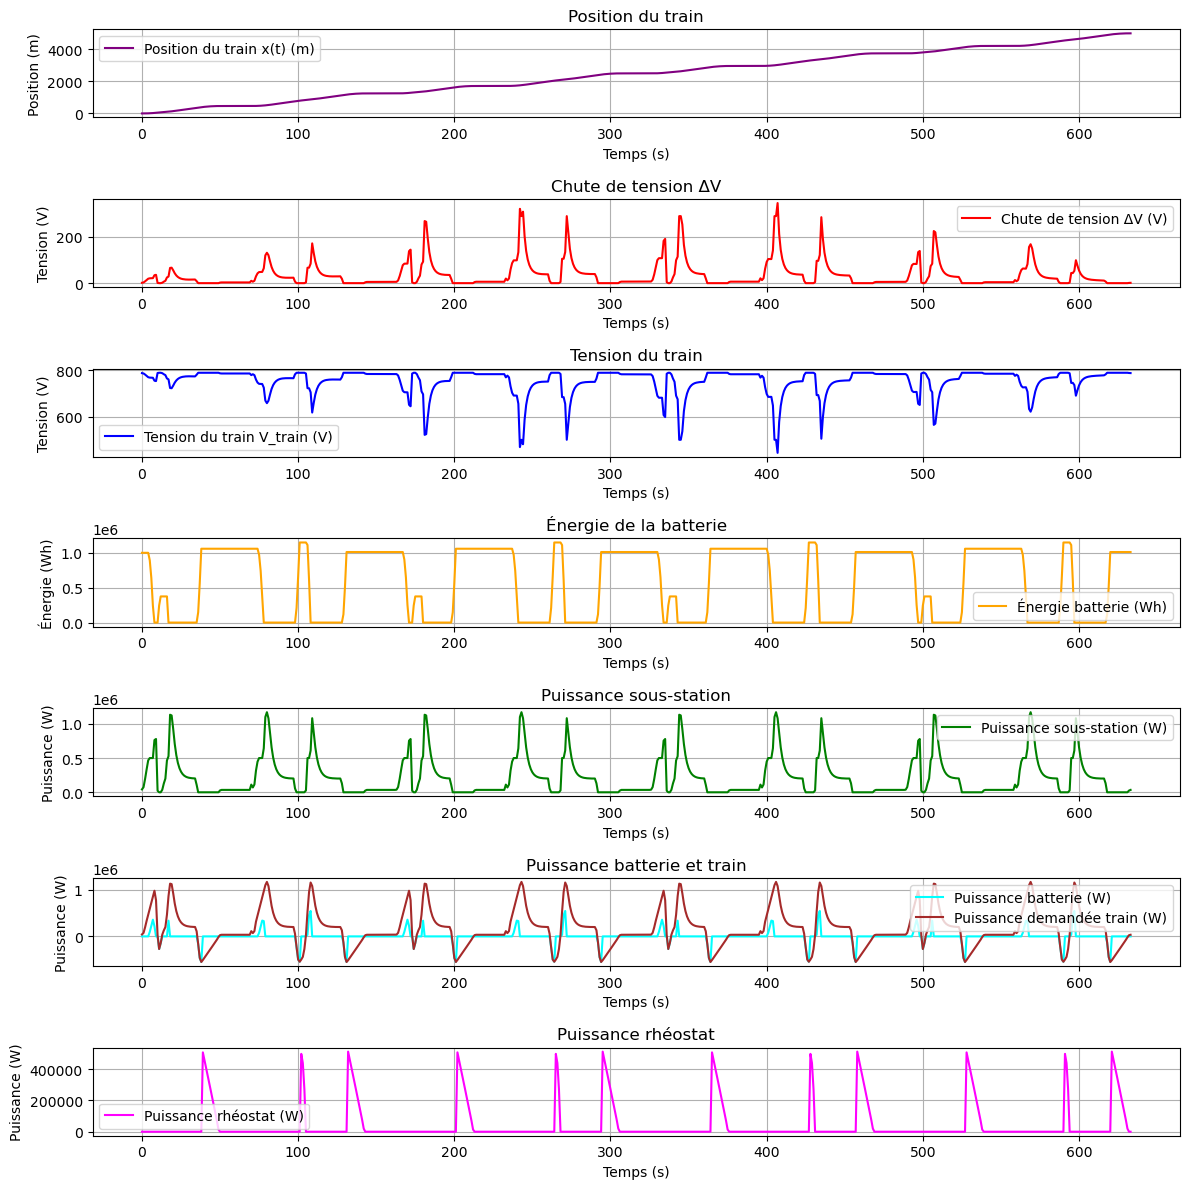

In [23]:
# Paramètres de la batterie
Seuil = 0.5* 1e6  # Seuil de puissance (W)
E_batterie_max = 1e6 # Capacité maximale de la batterie (Wh)
E_batterie_actuelle = E_batterie_max  # Capacité initiale de la batterie (Wh)

# Initialisation des variables pour stocker les résultats
P_batt_results = []  # Puissance batterie
P_train_results = []  # Puissance demandée par le train
P_lac_results = []  # Puissance sous-station
E_batterie_results = []  # Énergie de la batterie
P_rh_results = []  # Puissance rhéostat
delta_v_results = []  # Chute de tension
V_sst_results = []  # Tension sous-station
v_tr = []  # Tension du train

# Simulation
for i in range(len(time)):
    dt = time[i] - time[i - 1] if i > 0 else 1  # Intervalle de temps
    P_train = P_electrique_results[i]  # Puissance demandée par le train
    P_rh = 0  # Initialisation de la puissance du rhéostat

    if P_train < 0:  # Recharge (freinage)
        if E_batterie_actuelle < E_batterie_max:
            P_lac = 0
            P_rh = 0
            P_batt = P_train  # Recharge de la batterie
            E_batterie_actuelle -= P_batt * dt * 0.9  # Efficacité de la recharge
        else:
            P_lac = 0
            P_batt = 0  # Batterie pleine
            P_rh = -P_train  # Dissipation par le rhéostat
    elif P_train >= 0:  # Décharge (consommation)
        P_rh = 0
        if P_train <= Seuil:
            P_lac = P_train  # La sous-station fournit toute la puissance
            P_batt = 0
        else:
            P_lac = Seuil  # La sous-station fournit au maximum jusqu'au seuil
            if E_batterie_actuelle > 0:
                P_batt = P_train - P_lac  # La batterie complète la puissance
                # On limite si l'énergie de la batterie est insuffisante
                max_batt = E_batterie_actuelle * 0.9 / dt
                '''Cette condition vérifie si la puissance demandée à la batterie (P_batt) dépasse la puissance maximale que la batterie peut fournir (max_batt_power).
'''
                if P_batt > max_batt:
                    P_batt = max_batt
                E_batterie_actuelle -= P_batt * dt / 0.9  # Mise à jour de l'énergie de la batterie
            else:
                P_batt = 0  # Batterie vide
            P_lac = P_train - P_batt  # Recalculer la puissance sous-station

    # Calcul des résistances 
    x_pos = position[i]
    R_LAC1 = rho_LAC * x_pos
    R_rail1 = rho_rail * x_pos
    R_LAC2 = rho_LAC * (position[-1] - x_pos)
    R_rail2 = rho_rail * (position[-1] - x_pos)

    R_haut = R_LAC1 + R_rail1 + R_internal
    R_bas = R_LAC2 + R_rail2 + R_internal
    R_eq = (R_haut * R_bas) / (R_haut + R_bas)

    # Calcul de la tension aux bornes du train
    discriminant = V_source**2 - 4 * R_eq * (P_lac )
    if discriminant >= 0:
        V_train = (V_source + np.sqrt(discriminant)) / 2
    else:
        V_train = 500  # Valeur par défaut si discriminant négatif

    delta_v = abs(V_source - V_train)

    # Stockage des résultats
    P_batt_results.append(P_batt)
    P_train_results.append(P_train)
    P_lac_results.append(P_lac)
    E_batterie_results.append(E_batterie_actuelle)
    P_rh_results.append(P_rh)
    delta_v_results.append(delta_v)
    V_sst_results.append(V_source)
    v_tr.append(V_train)

delta_v_max = np.max(delta_v_results)

# Visualisation des résultats
plt.figure(figsize=(12, 12))

plt.subplot(7, 1, 1)
plt.plot(time, position, label="Position du train x(t) (m)", color="purple")
plt.xlabel("Temps (s)")
plt.ylabel("Position (m)")
plt.title("Position du train")
plt.legend()
plt.grid()

plt.subplot(7, 1, 2)
plt.plot(time, delta_v_results, label="Chute de tension ΔV (V)", color="red")
plt.xlabel("Temps (s)")
plt.ylabel("Tension (V)")
plt.title("Chute de tension ΔV")
plt.legend()
plt.grid()

plt.subplot(7, 1, 3)
plt.plot(time, v_tr, label="Tension du train V_train (V)", color="blue")
plt.xlabel("Temps (s)")
plt.ylabel("Tension (V)")
plt.title("Tension du train")
plt.legend()
plt.grid()

plt.subplot(7, 1, 4)
plt.plot(time, E_batterie_results, label="Énergie batterie (Wh)", color="orange")
plt.xlabel("Temps (s)")
plt.ylabel("Énergie (Wh)")
plt.title("Énergie de la batterie")
plt.legend()
plt.grid()

plt.subplot(7, 1, 5)
plt.plot(time, P_lac_results, label="Puissance sous-station (W)", color="green")
plt.xlabel("Temps (s)")
plt.ylabel("Puissance (W)")
plt.title("Puissance sous-station")
plt.legend()
plt.grid()

plt.subplot(7, 1, 6)
plt.plot(time, P_batt_results, label="Puissance batterie (W)", color="cyan")
plt.plot(time, P_electrique_results, label="Puissance demandée train (W)", color="brown")
plt.xlabel("Temps (s)")
plt.ylabel("Puissance (W)")
plt.title("Puissance batterie et train")
plt.legend()
plt.grid()

plt.subplot(7, 1, 7)
plt.plot(time, P_rh_results, label="Puissance rhéostat (W)", color="magenta")
plt.xlabel("Temps (s)")
plt.ylabel("Puissance (W)")
plt.title("Puissance rhéostat")
plt.legend()
plt.grid()

plt.tight_layout()
plt.show()


In [24]:
# Afficher delta_v_max
print(f"La chute de tension maximale (delta_v_max) est : {delta_v_max} V")

La chute de tension maximale (delta_v_max) est : 346.5784335364823 V
